## Interim Report Analysis

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

print ("Imports successful")

Imports successful


## Defining Uncertainty Words 
Prior to the analyzing the transcripts, we're pulling in the list of uncertainty words that Loughran_McDonald listed

In [6]:
uncertainty_words = {
    'may', 'might', 'could', 'possibly', 'uncertain', 'uncertainty',
    'risk', 'risks', 'approximately', 'believe', 'believes', 'depends',
    'fluctuate', 'indefinite', 'estimate', 'estimates', 'potential',
    'variable', 'contingent', 'anticipate', 'outlook', 'probable',
    'appears', 'seem', 'seems', 'pending', 'predict', 'roughly'
}

print(f"Loaded {len(uncertainty_words)} uncertainty_words")

Loaded 28 uncertainty_words


In [15]:
# Companies and quarters
companies = {
    'NVDA': 'NVIDIA',
    'MSFT': 'Microsoft'
}
quarters = ['Q1_2025', 'Q2_2025', 'Q3_2025', 'Q4_2025']

all_results = []

# Process each company
for ticker, name in companies.items():
    print(f"\n{'='*60}")
    print(f"Processing {name} ({ticker}) - FY2025")
    print('='*60)
    
    for quarter in quarters:
        filename = f'{ticker}_{quarter}.txt'
        
        try:
            with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read()
            
            # Try multiple Q&A markers
            qa_section = None
            markers = ["Question-and-Answer", "Q&A Session", "Question and Answer", 
          "Operator", "Questions and Answers", "Q & A",
          "your first question comes from"]
            
            for marker in markers:
                if marker in text:
                    qa_section = text.split(marker, 1)[1]
                    break
            
            if qa_section is None:
                print(f"  ⚠️  {quarter}: Using full transcript (no Q&A marker found)")
                qa_section = text
            
            # Count words
            words = qa_section.lower().split()
            total_words = len(words)
            uncertainty_count = sum(1 for w in words if w in uncertainty_words)
            percentage = (uncertainty_count / total_words) * 100
            
            all_results.append({
                'Company': ticker,
                'Company_Name': name,
                'Quarter': quarter,
                'Total_Words': total_words,
                'Uncertainty_Count': uncertainty_count,
                'Density_%': round(percentage, 2)
            })
            
            print(f"  ✓ {quarter}: {total_words:,} words, {percentage:.2f}% uncertainty")
            
        except FileNotFoundError:
            print(f"  ✗ {quarter}: FILE NOT FOUND - {filename}")
            print(f"      Check that file exists and name matches exactly")

print(f"\n✓ Processed {len(all_results)} transcripts total")


Processing NVIDIA (NVDA) - FY2025
  ✓ Q1_2025: 8,168 words, 0.43% uncertainty
  ✓ Q2_2025: 8,765 words, 0.48% uncertainty
  ✓ Q3_2025: 8,194 words, 0.52% uncertainty
  ✓ Q4_2025: 5,157 words, 0.45% uncertainty

Processing Microsoft (MSFT) - FY2025
  ✓ Q1_2025: 9,320 words, 0.32% uncertainty
  ✓ Q2_2025: 8,823 words, 0.29% uncertainty
  ✓ Q3_2025: 8,080 words, 0.45% uncertainty
  ✓ Q4_2025: 8,052 words, 0.38% uncertainty

✓ Processed 8 transcripts total


In [16]:
# Print results table
print("\n" + "="*70)
print("COMPLETE RESULTS TABLE - FY2025")
print("="*70)
print(f"{'Company':<12} {'Quarter':<12} {'Total Words':<15} {'Unc. Words':<12} {'Density %':<10}")
print("-"*70)
for r in all_results:
    print(f"{r['Company_Name']:<12} {r['Quarter']:<12} {r['Total_Words']:<15,} {r['Uncertainty_Count']:<12} {r['Density_%']:<10}")


COMPLETE RESULTS TABLE - FY2025
Company      Quarter      Total Words     Unc. Words   Density % 
----------------------------------------------------------------------
NVIDIA       Q1_2025      8,168           35           0.43      
NVIDIA       Q2_2025      8,765           42           0.48      
NVIDIA       Q3_2025      8,194           43           0.52      
NVIDIA       Q4_2025      5,157           23           0.45      
Microsoft    Q1_2025      9,320           30           0.32      
Microsoft    Q2_2025      8,823           26           0.29      
Microsoft    Q3_2025      8,080           36           0.45      
Microsoft    Q4_2025      8,052           31           0.38      


✓ Chart saved as 'uncertainty_comparison_2025.png'


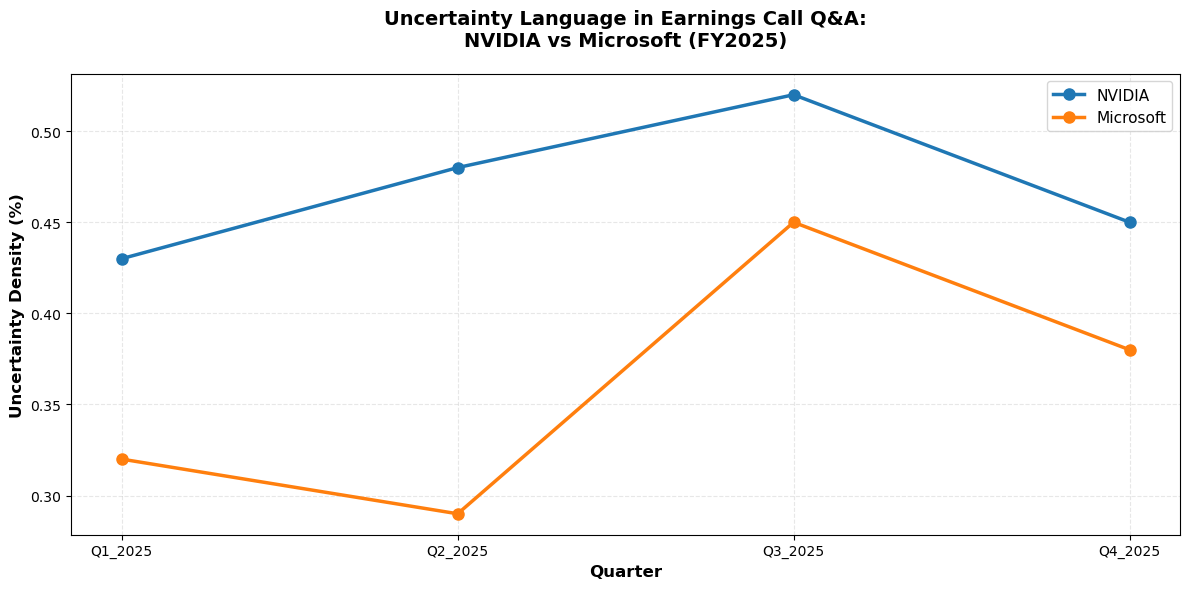

In [17]:
# Create comparison chart
fig, ax = plt.subplots(figsize=(12, 6))

for ticker, name in companies.items():
    company_data = [r for r in all_results if r['Company'] == ticker]
    quarters_list = [r['Quarter'] for r in company_data]
    densities = [r['Density_%'] for r in company_data]
    
    ax.plot(quarters_list, densities, marker='o', linewidth=2.5, 
            markersize=8, label=name)

ax.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax.set_ylabel('Uncertainty Density (%)', fontsize=12, fontweight='bold')
ax.set_title('Uncertainty Language in Earnings Call Q&A:\nNVIDIA vs Microsoft (FY2025)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Save the chart
plt.savefig('uncertainty_comparison_2025.png', dpi=300, bbox_inches='tight')
print("✓ Chart saved as 'uncertainty_comparison_2025.png'")

# Display in notebook
plt.show()

In [18]:
# Calculate summary stats
print("\n" + "="*70)
print("SUMMARY STATISTICS - FY2025")
print("="*70)

for ticker, name in companies.items():
    company_data = [r for r in all_results if r['Company'] == ticker]
    densities = [r['Density_%'] for r in company_data]
    avg = sum(densities)/len(densities)
    
    print(f"\n{name}:")
    print(f"  Average uncertainty: {avg:.2f}%")
    print(f"  Range: {min(densities):.2f}% - {max(densities):.2f}%")
    print(f"  Trend: {'Increasing' if densities[-1] > densities[0] else 'Decreasing' if densities[-1] < densities[0] else 'Stable'}")

# Save to CSV
with open('results_2025.csv', 'w') as f:
    f.write("Company,Quarter,Total_Words,Uncertainty_Count,Density_%\n")
    for r in all_results:
        f.write(f"{r['Company']},{r['Quarter']},{r['Total_Words']},{r['Uncertainty_Count']},{r['Density_%']}\n")
        
print("\n✓ Results saved to 'results_2025.csv'")


SUMMARY STATISTICS - FY2025

NVIDIA:
  Average uncertainty: 0.47%
  Range: 0.43% - 0.52%
  Trend: Increasing

Microsoft:
  Average uncertainty: 0.36%
  Range: 0.29% - 0.45%
  Trend: Increasing

✓ Results saved to 'results_2025.csv'


In [20]:
import re

def extract_revenue(filename):
    """
    Extract quarterly revenue from earnings call transcript.
    Handles multiple common phrasings.
    """
    try:
        with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read()
        
        # Take first ~5000 characters (where revenue is typically mentioned)
        intro_section = text[:5000]
        
        # Expanded patterns for different phrasings
        patterns = [
            r'This quarter revenue was \$?(\d+\.?\d*) billion',  # Microsoft style
            r'revenue (?:of|was) \$?(\d+\.?\d*) billion',         # NVIDIA style
            r'revenue.*?\$(\d+\.?\d*) billion',
            r'\$(\d+\.?\d*) billion.*?revenue',
            r'Q\d.*?revenue.*?\$?(\d+\.?\d*)',
        ]
        
        for pattern in patterns:
            match = re.search(pattern, intro_section, re.IGNORECASE)
            if match:
                revenue = float(match.group(1))
                return revenue
        
        return None
        
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None

# Extract revenues for all transcripts
print("="*60)
print("EXTRACTING REVENUE FROM TRANSCRIPTS")
print("="*60)

revenue_data = {}

for ticker, name in companies.items():
    revenue_data[ticker] = {}
    print(f"\n{name}:")
    
    for quarter in quarters:
        filename = f'{ticker}_{quarter}.txt'
        revenue = extract_revenue(filename)
        revenue_data[ticker][quarter] = revenue
        
        if revenue:
            print(f"  {quarter}: ${revenue}B")
        else:
            print(f"  {quarter}: ⚠️  Revenue not found")

print("\n✓ Revenue extraction complete")

EXTRACTING REVENUE FROM TRANSCRIPTS

NVIDIA:
  Q1_2025: $26.0B
  Q2_2025: $30.0B
  Q3_2025: $35.1B
  Q4_2025: $39.3B

Microsoft:
  Q1_2025: $10.0B
  Q2_2025: $13.0B
  Q3_2025: $42.0B
  Q4_2025: $168.0B

✓ Revenue extraction complete


In [21]:
# MANUAL FIX: Pattern caught wrong Microsoft numbers
# Correcting based on actual earnings reports

print("\n⚠️  Microsoft auto-extraction picked up wrong numbers")
print("Applying manual corrections...\n")

revenue_data['MSFT'] = {
    'Q1_2025': 65.6,  # FY2025 Q1 (Jul-Sep 2024)
    'Q2_2025': 69.6,  # FY2025 Q2 (Oct-Dec 2024)
    'Q3_2025': 70.1,  # FY2025 Q3 (Jan-Mar 2025)
    'Q4_2025': 76.4,  # FY2025 Q4 (Apr-Jun 2025)
}

print("Microsoft revenues (manually corrected):")
for q, rev in revenue_data['MSFT'].items():
    print(f"  {q}: ${rev}B")
    
print("\nNVIDIA revenues (auto-extracted - accurate):")
for q, rev in revenue_data['NVDA'].items():
    print(f"  {q}: ${rev}B")


⚠️  Microsoft auto-extraction picked up wrong numbers
Applying manual corrections...

Microsoft revenues (manually corrected):
  Q1_2025: $65.6B
  Q2_2025: $69.6B
  Q3_2025: $70.1B
  Q4_2025: $76.4B

NVIDIA revenues (auto-extracted - accurate):
  Q1_2025: $26.0B
  Q2_2025: $30.0B
  Q3_2025: $35.1B
  Q4_2025: $39.3B


In [22]:
# Calculate revenue growth rates
import pandas as pd

analysis_data = []

for ticker, name in companies.items():
    company_results = [r for r in all_results if r['Company'] == ticker]
    
    for i, r in enumerate(company_results):
        quarter = r['Quarter']
        uncertainty = r['Density_%']
        revenue = revenue_data[ticker].get(quarter)
        
        # Skip if revenue not found
        if revenue is None:
            continue
        
        # Calculate QoQ revenue growth if not first quarter
        if i > 0:
            prev_quarter = company_results[i-1]['Quarter']
            prev_revenue = revenue_data[ticker].get(prev_quarter)
            if prev_revenue:
                revenue_growth = ((revenue - prev_revenue) / prev_revenue) * 100
            else:
                revenue_growth = None
        else:
            revenue_growth = None
        
        analysis_data.append({
            'Company': name,
            'Quarter': quarter,
            'Revenue_$B': revenue,
            'Revenue_Growth_%': round(revenue_growth, 1) if revenue_growth else None,
            'Uncertainty_%': uncertainty
        })

df_analysis = pd.DataFrame(analysis_data)
print("\n" + "="*80)
print("REVENUE vs UNCERTAINTY ANALYSIS")
print("="*80)
print(df_analysis.to_string(index=False))

# Show correlation
print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)
for ticker, name in companies.items():
    company_df = df_analysis[df_analysis['Company'] == name]
    # Remove rows with None in Revenue_Growth
    company_df_clean = company_df.dropna(subset=['Revenue_Growth_%'])
    if len(company_df_clean) > 1:
        correlation = company_df_clean['Revenue_Growth_%'].corr(company_df_clean['Uncertainty_%'])
        print(f"{name}: Revenue Growth vs Uncertainty correlation = {correlation:.3f}")
        if correlation < 0:
            print(f"  → Negative correlation: Higher uncertainty when growth slows")
        elif correlation > 0:
            print(f"  → Positive correlation: Higher uncertainty with faster growth")
        else:
            print(f"  → No clear correlation")


REVENUE vs UNCERTAINTY ANALYSIS
  Company Quarter  Revenue_$B  Revenue_Growth_%  Uncertainty_%
   NVIDIA Q1_2025        26.0               NaN           0.43
   NVIDIA Q2_2025        30.0              15.4           0.48
   NVIDIA Q3_2025        35.1              17.0           0.52
   NVIDIA Q4_2025        39.3              12.0           0.45
Microsoft Q1_2025        65.6               NaN           0.32
Microsoft Q2_2025        69.6               6.1           0.29
Microsoft Q3_2025        70.1               0.7           0.45
Microsoft Q4_2025        76.4               9.0           0.38

CORRELATION ANALYSIS
NVIDIA: Revenue Growth vs Uncertainty correlation = 0.959
  → Positive correlation: Higher uncertainty with faster growth
Microsoft: Revenue Growth vs Uncertainty correlation = -0.584
  → Negative correlation: Higher uncertainty when growth slows


✓ Chart saved as 'revenue_vs_uncertainty.png'


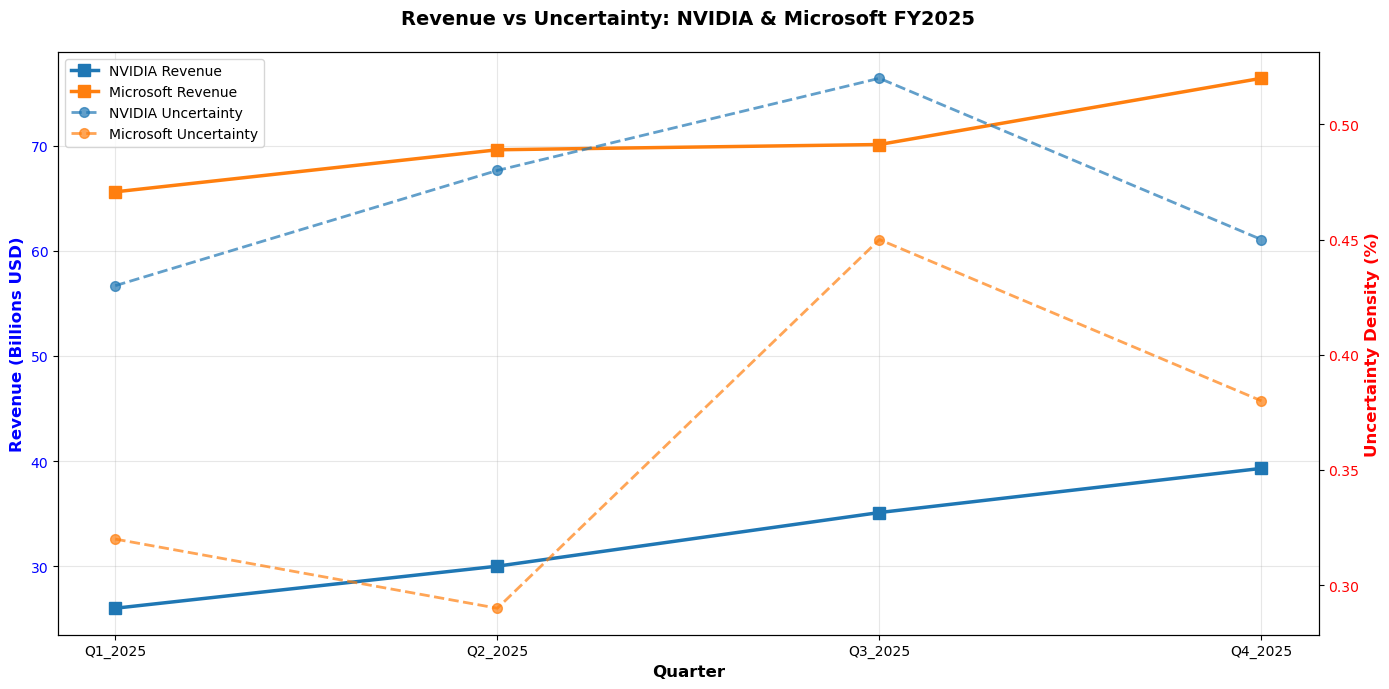

In [23]:
# Create dual-axis chart showing revenue and uncertainty together
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot for each company
for ticker, name in companies.items():
    company_data = df_analysis[df_analysis['Company'] == name]
    
    # Revenue on left axis
    ax1.plot(company_data['Quarter'], company_data['Revenue_$B'], 
             marker='s', linewidth=2.5, markersize=8, label=f'{name} Revenue')

# Uncertainty on right axis
ax2 = ax1.twinx()
for ticker, name in companies.items():
    company_data = df_analysis[df_analysis['Company'] == name]
    
    ax2.plot(company_data['Quarter'], company_data['Uncertainty_%'], 
             marker='o', linewidth=2, markersize=7, linestyle='--', 
             label=f'{name} Uncertainty', alpha=0.7)

# Labels and formatting
ax1.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue (Billions USD)', fontsize=12, fontweight='bold', color='blue')
ax2.set_ylabel('Uncertainty Density (%)', fontsize=12, fontweight='bold', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Revenue vs Uncertainty: NVIDIA & Microsoft FY2025', 
          fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('revenue_vs_uncertainty.png', dpi=300, bbox_inches='tight')
print("✓ Chart saved as 'revenue_vs_uncertainty.png'")
plt.show()